In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data= pd.read_csv("C:\\Users\\lenovo\\Downloads\\Mall_Customers.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
data.rename(columns = {'Annual Income (k$)' : 'Annual Income','Spending Score (1-100)':'Spending Score'}, inplace= True)
data.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


c:\Users\lenovo\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


AttributeError: module 'matplotlib' has no attribute 'show'

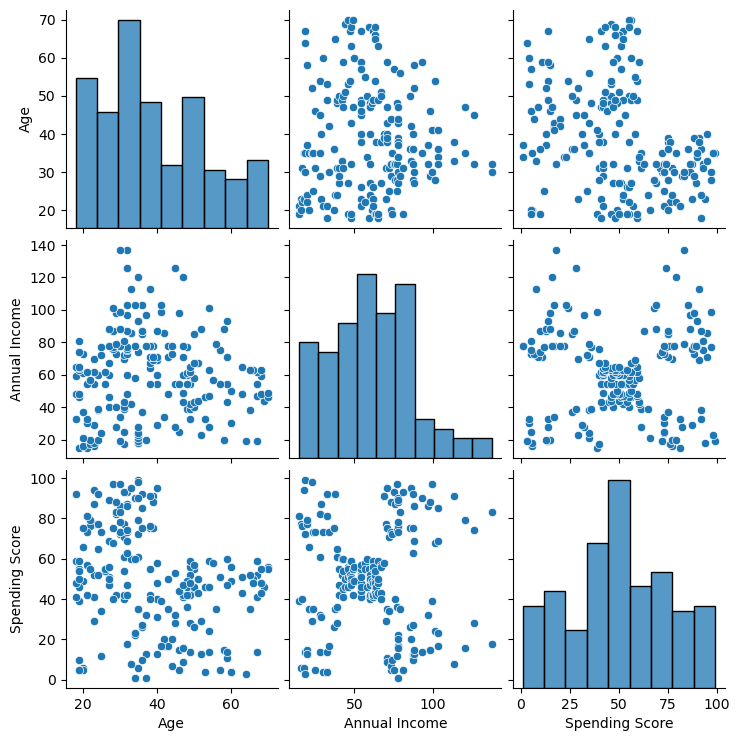

In [5]:
sns.pairplot(data[['Age','Annual Income','Spending Score']])
plt.show()

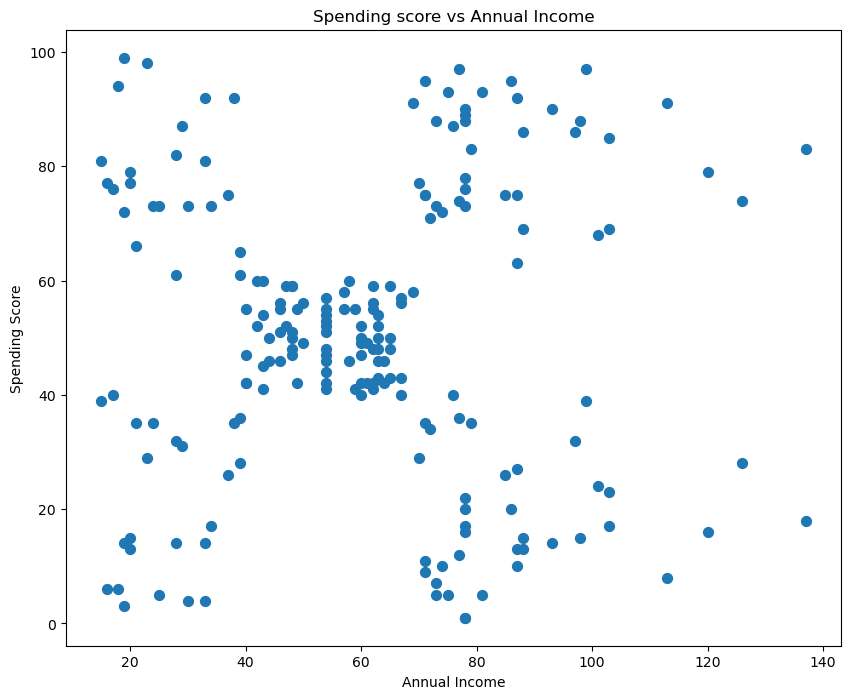

In [8]:
plt.figure(figsize = (10,8))
plt.scatter(data['Annual Income'],data['Spending Score'],s=50)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Spending score vs Annual Income')
plt.show()


In [9]:
from sklearn.cluster import KMeans

In [16]:
x= data[['Annual Income','Spending Score']]
wcss=[]

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init ='k-means++',max_iter=300,n_init=10,random_state =0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

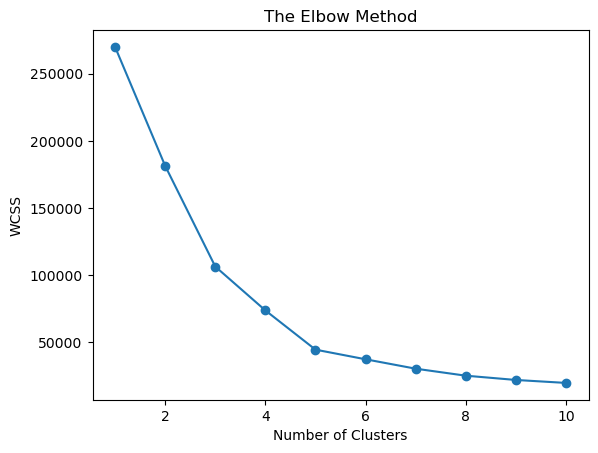

In [17]:
plt.plot(range(1,11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [32]:
kmeans = KMeans(n_clusters=5,init ='k-means++',max_iter=300,n_init=10,random_state =0)
y_kmean =kmeans.fit_predict(x)

In [33]:
data['cluster']= y_kmean
data.head()

,CustomerID,Gender,Age,Annual Income,Spending Score,cluster,cluster Age
0,1,Male,19,15,39,3,3
1,2,Male,21,15,81,2,1
2,3,Female,20,16,6,1,2
3,4,Female,23,16,77,2,1
4,5,Female,31,17,40,3,3


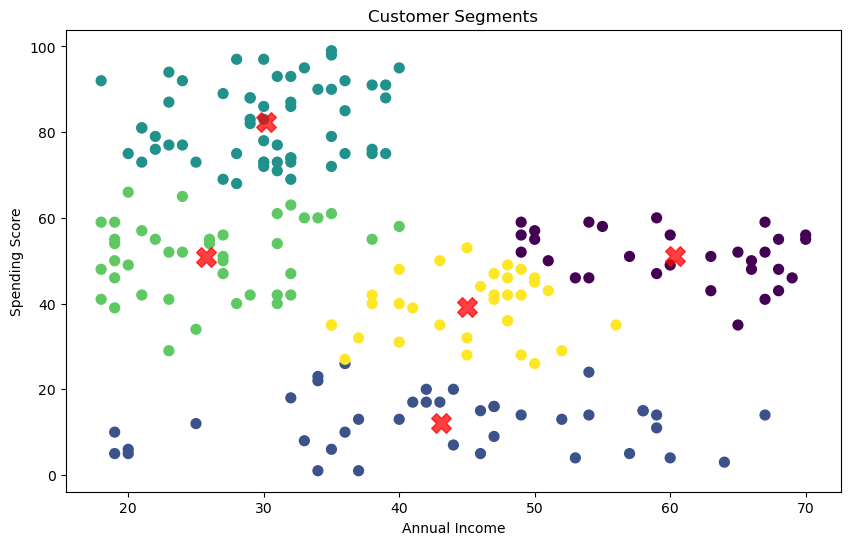

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=y_kmean, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],c='red', s=200, alpha=0.75, marker='X')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')
plt.show()


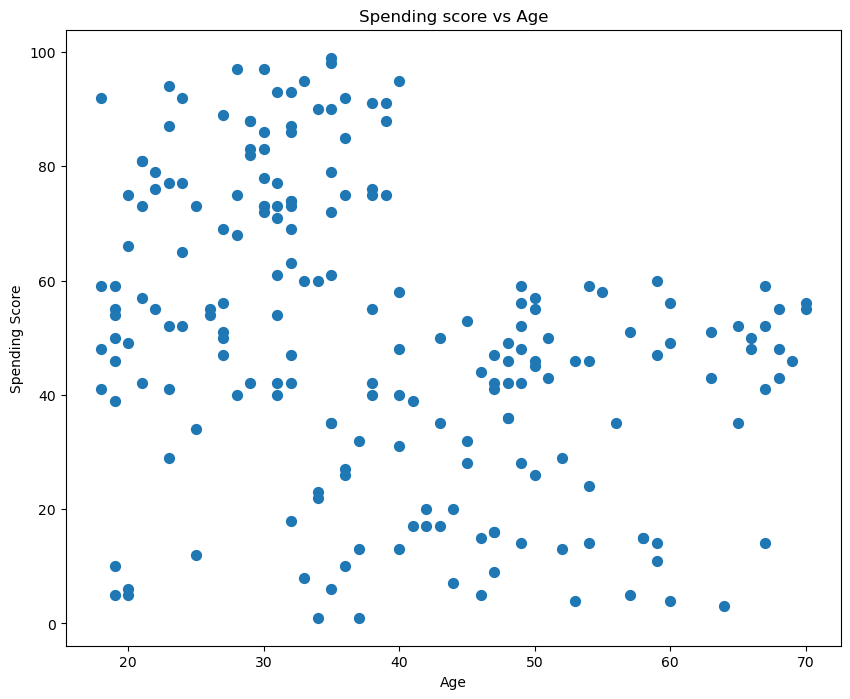

In [25]:
plt.figure(figsize = (10,8))
plt.scatter(data['Age'],data['Spending Score'],s=50)
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('Spending score vs Age')
plt.show()


In [21]:
x= data[['Age','Spending Score']]
wcss=[]

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init ='k-means++',max_iter=300,n_init=10,random_state =0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

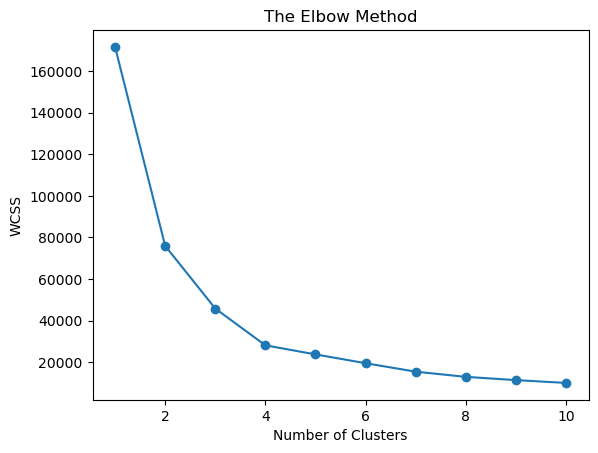

In [22]:
plt.plot(range(1,11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [43]:
kmeans = KMeans(n_clusters=4,init ='k-means++',max_iter=300,n_init=10,random_state =0)
y_kmean =kmeans.fit_predict(x)

In [44]:
data['cluster Age']= y_kmean
data.head()

,CustomerID,Gender,Age,Annual Income,Spending Score,cluster,cluster Age
0,1,Male,19,15,39,3,3
1,2,Male,21,15,81,2,1
2,3,Female,20,16,6,1,2
3,4,Female,23,16,77,2,1
4,5,Female,31,17,40,3,3


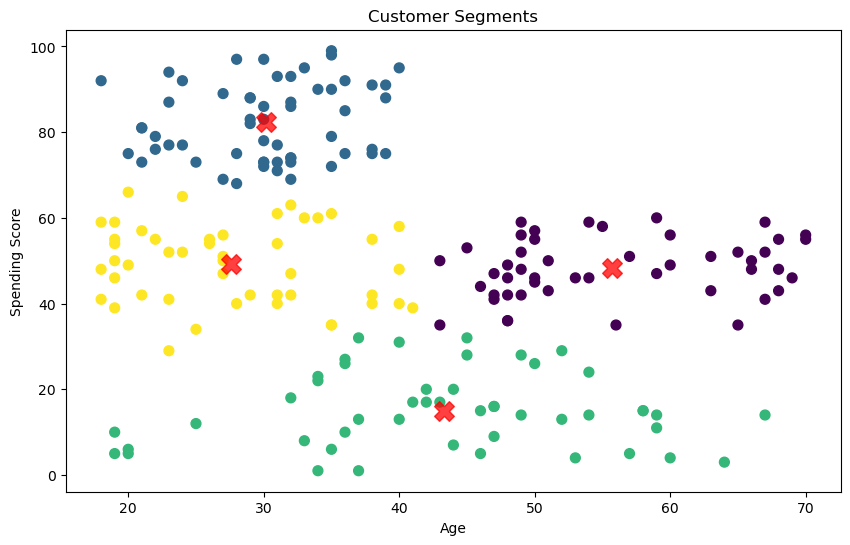

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=y_kmean, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('Customer Segments')
plt.show()
